# Hands-on example — NN vs PINN for ballistics

We consider the one-dimensional vertical motion of a projectile,

$$
\ddot{u}(t)+g=0,
$$

with initial conditions

$$
u(0)=u_0,
\qquad
\dot u(0)=v_0.
$$

The exact solution is

$$
u(t)=u_0+v_0t-\frac12gt^2.
$$

We will train two neural networks from noisy observations available only on the first half of the trajectory:

1. a standard data-driven neural network and
2. a physics-informed neural network (PINN) that also learns the unknown constant acceleration.

The PINN residual is
$$
r_\theta(t)=\ddot u_\theta(t)+\gamma,
$$

where $\gamma$ is a trainable scalar. If the physical model is correctly identified, $\gamma$ should approach $g$.


## 1. Imports and reproducibility


In [1]:
import copy
import numpy as np
import torch
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

torch.manual_seed(123)
np.random.seed(123)

dtype = torch.float64

# Plotting colors.
color_nn = "black"
color_pinn = (0.2039, 0.4314, 0.7529)
torch.set_num_threads(1)

## 2. Reference ballistic trajectory

We generate a reference solution on

$$
0\le t\le1\ \mathrm{s}
$$

using an ODE solver. This reference is used only to generate synthetic observations and to assess the learned models.


In [2]:
# Physical parameters used only to generate the synthetic reference solution.
u0 = 0.0       # m
v0 = 5.0       # m/s
g = 9.81       # m/s^2

t_start = 0.0
t_end = 1.0


def projectile_motion(t, state):
    """First-order system equivalent to u_tt + g = 0."""
    u, v = state
    return [v, -g]


X = np.linspace(t_start, t_end, 100, dtype=np.float32)

sol = solve_ivp(
    projectile_motion,
    [t_start, t_end],
    [u0, v0],
    t_eval=X,
)

y = sol.y[0].astype(np.float32)


## 3. Noisy training observations

Only observations in approximately

$$
0\le t\le0.5\ \mathrm{s}
$$

are provided during training. The second half of the trajectory is therefore an extrapolation region.

We perturb the displacement multiplicatively,

$$
u_i^{\mathrm{obs}}
=
u(t_i)\left(1+\epsilon_i\right),
\qquad
\epsilon_i\sim\mathcal N(0,\sigma^2).
$$


In [3]:
# Subsample the first half of the trajectory.
t_i_np = X[0:50:2].copy()
u_i_np = y[0:50:2].copy()

sigma = 0.10
u_i_np += sigma * np.random.normal(0.0, 1.0, len(u_i_np)) * u_i_np
u_i_np[0] = 0.0

t_i = torch.tensor(t_i_np, dtype=dtype).view(-1, 1)
u_i = torch.tensor(u_i_np, dtype=dtype).view(-1, 1)

print(f"number of observations: {len(t_i)}")
print(f"training interval: [{t_i.min().item():.2f}, {t_i.max().item():.2f}] s")


number of observations: 25
training interval: [0.00, 0.48] s


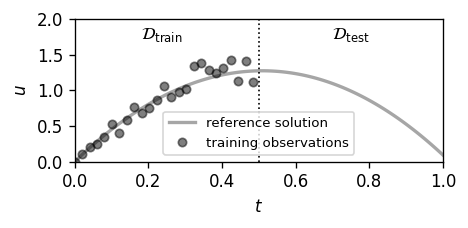

In [4]:
fig, ax = plt.subplots(dpi=120, figsize=(4, 2), tight_layout=False)

ax.plot(X, y, color="black", linewidth=2, alpha=0.35, label="reference solution")
ax.plot(
    t_i.numpy(),
    u_i.numpy(),
    marker="o",
    linestyle="none",
    color="black",
    markersize=5,
    alpha=0.5,
    label="training observations",
)

ax.axvline(0.5, color="black", linestyle=":", linewidth=1)
ax.text(0.18, 1.72, r"$\mathcal{D}_{\mathrm{train}}$")
ax.text(0.70, 1.72, r"$\mathcal{D}_{\mathrm{test}}$")

ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, 2.0)
ax.set_xlabel(r"$t$")
ax.set_ylabel(r"$u$")
ax.legend(loc='lower center', fontsize=8)
plt.show()


## 4. Neural-network model

Both models use exactly the same architecture: two hidden layers with 12 neurons each and `tanh` activations.

The PINN additionally contains the trainable scalar \(\gamma\). For the standard NN, this parameter is frozen so that it plays no role.


In [5]:
class NeuralNet(torch.nn.Module):
    """Fully-connected neural network for u_theta(t)."""

    def __init__(
        self,
        hidden_layers=(12, 12),
        dtype=torch.float32,
        learn_gamma=False,
    ):
        super().__init__()

        layers = []
        in_dim = 1

        for width in hidden_layers:
            layers.append(torch.nn.Linear(in_dim, width, dtype=dtype))
            layers.append(torch.nn.Tanh())
            in_dim = width

        layers.append(torch.nn.Linear(in_dim, 1, dtype=dtype))

        self.NN = torch.nn.Sequential(*layers)

        # Unknown constant acceleration used only by the PINN.
        self.gamma = torch.nn.Parameter(
            torch.tensor(1.0, dtype=dtype),
            requires_grad=learn_gamma,
        )

    def forward(self, t):
        return self.NN(t)


# Start both models from the same neural-network weights.
base_model = NeuralNet(dtype=dtype)

model_nn = copy.deepcopy(base_model)

model_pinn = copy.deepcopy(base_model)
model_pinn.gamma.requires_grad_(True)

print(
    "network parameters:",
    sum(p.numel() for p in base_model.NN.parameters()),
)


network parameters: 193


## 5. Why use an optimizer closure?

A PyTorch closure is a function that:

1. clears existing gradients;
2. evaluates the current loss;
3. backpropagates that loss;
4. returns the scalar loss.

For Adam, using a closure is optional. For `torch.optim.LBFGS`, however, a closure is essential because L-BFGS may need to reevaluate the objective and its gradients several times during a single optimization step.

We use the same pattern for both optimizers:

```python
def closure():
    optimizer.zero_grad()
    loss = ...
    loss.backward()
    return loss

optimizer.step(closure)
```

This keeps the definition of the optimization problem separate from the choice of optimizer.


## 6. Standard neural network

The data-driven NN minimizes only

$$
L_{\mathrm{data}}(\theta)
=
\frac{1}{N}
\sum_{i=1}^N
\left(
u_\theta(t_i)-u_i^{\mathrm{obs}}
\right)^2.
$$

The network is never told that the trajectory must satisfy a differential equation.


In [6]:
def data_loss(model):
    """Mean-squared error on the observed trajectory."""
    u_pred = model(t_i)
    return torch.mean((u_pred - u_i) ** 2)


def parameter_norms(model):
    """Return l1 and l2 norms of the neural-network parameters."""
    l1 = torch.tensor(0.0, dtype=dtype)
    l2_sq = torch.tensor(0.0, dtype=dtype)

    for p in model.NN.parameters():
        l1 = l1 + torch.sum(torch.abs(p))
        l2_sq = l2_sq + torch.sum(p**2)

    return l1, torch.sqrt(l2_sq)


def make_data_closure(model, optimizer):
    """Closure used by either Adam or L-BFGS."""
    def closure():
        optimizer.zero_grad(set_to_none=True)
        loss = data_loss(model)
        loss.backward()
        return loss

    return closure


In [7]:
# --- Adam phase -------------------------------------------------------------
n_adam = 40_000
report_every = 1_000

optimizer = torch.optim.Adam(
    [p for p in model_nn.parameters() if p.requires_grad],
    lr=1e-2,
)
closure = make_data_closure(model_nn, optimizer)

nn_loss_history = []
nn_l1_history = []
nn_l2_history = []
nn_history_steps = []

for step in range(n_adam):
    loss = optimizer.step(closure)

    if step % report_every == 0:
        l1, l2 = parameter_norms(model_nn)

        nn_history_steps.append(step)
        nn_loss_history.append(loss.item())
        nn_l1_history.append(l1.item())
        nn_l2_history.append(l2.item())

        print(
            f"NN | Adam step {step:5d} | "
            f"L_data = {loss.item():.6e}"
        )


# --- L-BFGS refinement ------------------------------------------------------
optimizer = torch.optim.LBFGS(
    [p for p in model_nn.parameters() if p.requires_grad],
    lr=1.0,
    max_iter=50,
    line_search_fn="strong_wolfe",
)

# The optimizer changed, so the closure is rebuilt with the new optimizer.
closure = make_data_closure(model_nn, optimizer)
optimizer.step(closure)
l1, l2 = parameter_norms(model_nn)

nn_history_steps.append(step)
nn_loss_history.append(loss.item())
nn_l1_history.append(l1.item())
nn_l2_history.append(l2.item())


print(
    "NN | final L_data = "
    f"{data_loss(model_nn).item():.6e}"
)


NN | Adam step     0 | L_data = 1.444542e+00
NN | Adam step  1000 | L_data = 1.048040e-02
NN | Adam step  2000 | L_data = 7.631598e-03
NN | Adam step  3000 | L_data = 6.426850e-03
NN | Adam step  4000 | L_data = 5.468635e-03
NN | Adam step  5000 | L_data = 4.846829e-03
NN | Adam step  6000 | L_data = 4.640296e-03
NN | Adam step  7000 | L_data = 4.557215e-03
NN | Adam step  8000 | L_data = 4.535038e-03
NN | Adam step  9000 | L_data = 4.523803e-03
NN | Adam step 10000 | L_data = 4.672789e-03
NN | Adam step 11000 | L_data = 4.529691e-03
NN | Adam step 12000 | L_data = 4.496192e-03
NN | Adam step 13000 | L_data = 4.464074e-03
NN | Adam step 14000 | L_data = 4.068695e-03
NN | Adam step 15000 | L_data = 3.152592e-03
NN | Adam step 16000 | L_data = 2.384636e-03
NN | Adam step 17000 | L_data = 2.241783e-03
NN | Adam step 18000 | L_data = 2.176713e-03
NN | Adam step 19000 | L_data = 2.032342e-03
NN | Adam step 20000 | L_data = 2.043864e-03
NN | Adam step 21000 | L_data = 1.730947e-03
NN | Adam 

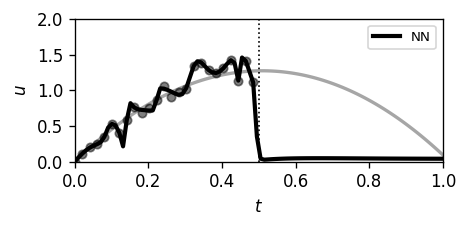

In [8]:
t_eval = torch.tensor(X, dtype=dtype).view(-1, 1)

with torch.no_grad():
    y_nn = model_nn(t_eval).squeeze().numpy()

fig, ax = plt.subplots(dpi=120, figsize=(4, 2), tight_layout=False)

ax.plot(X, y, color="black", linewidth=2, alpha=0.35)#, label="reference solution")
ax.plot(
    t_i.numpy(),
    u_i.numpy(),
    marker="o",
    linestyle="none",
    color="black",
    markersize=5,
    alpha=0.5,
    # label="training observations",
)
ax.plot(X, y_nn, color=color_nn, linewidth=2.5, label="NN")

ax.axvline(0.5, color="black", linestyle=":", linewidth=1)

ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, 2.0)
ax.set_xlabel(r"$t$")
ax.set_ylabel(r"$u$")
ax.legend(frameon=True, loc='best', fontsize=8)
plt.show()


The standard NN can fit the observed data well, but the extrapolated trajectory is unconstrained. Many functions can interpolate the observations on $0\le t\le0.5$.

## 7. Physics-informed neural network

The PINN uses two sources of information.

### Data term

$$
L_{\mathrm{data}}
=
\frac1N
\sum_i
\left(
u_\theta(t_i)-u_i^{\mathrm{obs}}
\right)^2.
$$

### Physics term

At collocation points $t_k^r$, automatic differentiation is used to compute

$$
\dot u_\theta(t_k^r),
\qquad
\ddot u_\theta(t_k^r),
$$

and the ballistic residual

$$
r_\theta(t_k^r)
=
\ddot u_\theta(t_k^r)+\gamma.
$$

Hence,

$$
L_{\mathrm{PDE}}
=
\frac{1}{N_r}
\sum_k r_\theta(t_k^r)^2.
$$

The joint objective is

$$
L
=
L_{\mathrm{data}}
+
\lambda_{\mathrm{PDE}}L_{\mathrm{PDE}}.
$$

Both $\theta$ and $\gamma$ are learned.


In [9]:
# Collocation points cover the entire interval on which physics is enforced.
t_k = torch.linspace(
    0.0, 1.0, 20, dtype=dtype
).view(-1, 1).requires_grad_(True)

lambda_PDE = 0.5


def physics_loss(model):
    """
    Compute the mean squared residual of

        u_tt + gamma = 0

    at the collocation points.
    """
    u_k = model(t_k)

    du_dt = torch.autograd.grad(
        u_k,
        t_k,
        grad_outputs=torch.ones_like(u_k),
        create_graph=True,
    )[0]

    d2u_dt2 = torch.autograd.grad(
        du_dt,
        t_k,
        grad_outputs=torch.ones_like(du_dt),
        create_graph=True,
    )[0]

    residual = d2u_dt2 + model.gamma

    return torch.mean(residual**2)


def pinn_loss(model):
    """Joint data + physics objective."""
    return data_loss(model) + lambda_PDE * physics_loss(model)


def make_pinn_closure(model, optimizer):
    """Closure used by either Adam or L-BFGS."""
    def closure():
        optimizer.zero_grad(set_to_none=True)
        loss = pinn_loss(model)
        loss.backward()
        return loss

    return closure


In [ ]:
# --- Adam phase -------------------------------------------------------------
n_adam = 40_000
report_every = 1_000

optimizer = torch.optim.Adam(
    [p for p in model_pinn.parameters() if p.requires_grad],
    lr=1e-2,
)
closure = make_pinn_closure(model_pinn, optimizer)

pinn_total_history = []
pinn_data_history = []
pinn_physics_history = []
pinn_gamma_history = []
pinn_l1_history = []
pinn_l2_history = []
pinn_history_steps = []

for step in range(n_adam):
    loss = optimizer.step(closure)

    if step % report_every == 0:
        # These evaluations build a graph because L_PDE contains derivatives,
        # but no backward pass is performed here.
        loss_data = data_loss(model_pinn)
        loss_pde = physics_loss(model_pinn)
        l1, l2 = parameter_norms(model_pinn)

        pinn_history_steps.append(step)
        pinn_total_history.append(loss.item())
        pinn_data_history.append(loss_data.item())
        pinn_physics_history.append(loss_pde.item())
        pinn_gamma_history.append(model_pinn.gamma.item())
        pinn_l1_history.append(l1.item())
        pinn_l2_history.append(l2.item())

        print(
            f"PINN | Adam step {step:5d} | "
            f"L_data = {loss_data.item():.6e} | "
            f"L_PDE = {loss_pde.item():.6e} | "
            f"gamma = {model_pinn.gamma.item():.4f}"
        )


# --- L-BFGS refinement ------------------------------------------------------
optimizer = torch.optim.LBFGS(
    [p for p in model_pinn.parameters() if p.requires_grad],
    lr=1.0,
    max_iter=50,
    line_search_fn="strong_wolfe",
)

closure = make_pinn_closure(model_pinn, optimizer)
optimizer.step(closure)

loss_data = data_loss(model_pinn)
loss_pde = physics_loss(model_pinn)
l1, l2 = parameter_norms(model_pinn)

pinn_history_steps.append(step)
pinn_total_history.append(loss.item())
pinn_data_history.append(loss_data.item())
pinn_physics_history.append(loss_pde.item())
pinn_gamma_history.append(model_pinn.gamma.item())
pinn_l1_history.append(l1.item())
pinn_l2_history.append(l2.item())

print()
print(f"true gravity g  = {g:.4f} m/s^2")
print(f"learned gamma   = {model_pinn.gamma.item():.4f} m/s^2")
print(f"final L_data    = {data_loss(model_pinn).item():.6e}")
print(f"final L_PDE     = {physics_loss(model_pinn).item():.6e}")


PINN | Adam step     0 | L_data = 1.201274e+00 | L_PDE = 9.856064e-01 | gamma = 0.9900
PINN | Adam step  1000 | L_data = 2.000140e-02 | L_PDE = 1.492424e-05 | gamma = 1.1806


The learned $\gamma$ need not equal $g$ exactly because the observations are noisy and the optimization problem balances data fitting against physical consistency. The key point is that the coefficient is inferred from the trajectory rather than supplied to the PINN.


In [ ]:
with torch.no_grad():
    y_nn = model_nn(t_eval).squeeze().numpy()
    y_pinn = model_pinn(t_eval).squeeze().numpy()

test_mask = X > 0.5

rmse_nn_test = np.sqrt(np.mean((y_nn[test_mask] - y[test_mask])**2))
rmse_pinn_test = np.sqrt(np.mean((y_pinn[test_mask] - y[test_mask])**2))

print(f"NN   extrapolation RMSE: {rmse_nn_test:.4e}")
print(f"PINN extrapolation RMSE: {rmse_pinn_test:.4e}")


In [ ]:
fig, ax = plt.subplots(dpi=130, figsize=(4, 2.0), tight_layout=False)

ax.plot(X, y, color="black", linewidth=2, alpha=0.30)#, label="reference solution")
ax.plot(
    t_i.numpy(),
    u_i.numpy(),
    marker="o",
    linestyle="none",
    color="black",
    markersize=5,
    alpha=0.45,
    # label="training observations",
)
ax.plot(X, y_nn, color=color_nn, linewidth=2.2, label="NN")
ax.plot(X, y_pinn, color=color_pinn, linewidth=2.5, label="PINN")

ax.axvline(0.5, color="black", linestyle=":", linewidth=1)

ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, 2.0)
ax.set_xlabel(r"$t$")
ax.set_ylabel(r"$u$")
ax.legend(frameon=True, loc='best', fontsize=8)
plt.show()


## 8. Inspect the learned physics

A PINN should not be assessed only from its trajectory. We can directly evaluate the residual

$$
r_\theta(t)
=
\ddot u_\theta(t)+\gamma.
$$

If the learned model satisfies the assumed governing equation, this quantity should remain close to zero throughout the collocation domain.


In [ ]:
t_res = torch.linspace(
    0.0, 1.0, 200, dtype=dtype
).view(-1, 1).requires_grad_(True)

u_res = model_pinn(t_res)

du_dt = torch.autograd.grad(
    u_res,
    t_res,
    grad_outputs=torch.ones_like(u_res),
    create_graph=True,
)[0]

d2u_dt2 = torch.autograd.grad(
    du_dt,
    t_res,
    grad_outputs=torch.ones_like(du_dt),
    create_graph=True,
)[0]

residual = (d2u_dt2 + model_pinn.gamma).detach().squeeze()

fig, ax = plt.subplots(dpi=120, figsize=(4, 2), tight_layout=False)
ax.plot(t_res.detach().squeeze(), residual, color=color_pinn, linewidth=2)
ax.axhline(0.0, color="black", linestyle="--", linewidth=1)

ax.set_xlabel(r"$t$")
ax.set_ylabel(r"$\ddot u_\theta+\gamma$")
plt.show()

print(
    "RMS physics residual:",
    f"{torch.sqrt(torch.mean(residual**2)).item():.4e}",
)


## 9. Physics as a learning bias

The physical residual restricts the class of trajectories accessible to the PINN. It therefore acts as a learning bias and often also has a regularizing effect.

For this small example, we compare the evolution of the $L^1$ and $L^2$ norms of the neural-network parameters during the Adam phase.


In [ ]:
fig, ax = plt.subplots(dpi=120, figsize=(3, 2), tight_layout=False)

ax.semilogx(
    nn_history_steps,
    nn_l1_history,
    color=color_nn,
    linewidth=2,
    label="NN",
)
ax.plot(
    pinn_history_steps,
    pinn_l1_history,
    color=color_pinn,
    linewidth=2,
    label="PINN",
)

ax.set_xlabel("Adam step")
ax.set_ylabel(r"$\|\theta\|_1$")
ax.legend(frameon=True,loc='best', fontsize=8)
plt.show()


fig, ax = plt.subplots(dpi=120, figsize=(3, 2), tight_layout=False)

ax.semilogx(
    nn_history_steps,
    nn_l2_history,
    color=color_nn,
    linewidth=2,
    label="NN",
)
ax.plot(
    pinn_history_steps,
    pinn_l2_history,
    color=color_pinn,
    linewidth=2,
    label="PINN",
)

ax.set_xlabel("Adam step")
ax.set_ylabel(r"$\|\theta\|_2$")
ax.legend(frameon=True,loc='best', fontsize=8)
plt.show()


## 10. Suggested experiments

1. Change the number of collocation points.
2. Enforce physics only on $0\le t\le0.5$ and compare extrapolation.
3. Change $\lambda_{\mathrm{PDE}}$.
4. Increase the observation noise.
5. Change the initial value of $\gamma$.
6. Remove the L-BFGS phase and compare the result.
7. Replace `tanh` by `ReLU`.

For the last experiment, remember that a ReLU network is piecewise linear. Its second derivative is zero almost everywhere, so a strong-form residual involving $\ddot u_\theta$ cannot provide the same useful training signal.

## Takeaways

- The data-driven NN minimizes only observation error.
- The PINN combines observation error with a differential-equation residual.
- Automatic differentiation supplies the derivatives needed by the residual.
- The unknown physical coefficient $\gamma$ can be optimized together with the network parameters.
- A closure cleanly packages loss evaluation and backpropagation and is required by L-BFGS.
- Physics mainly changes the extrapolation problem: the PINN is not free to continue the observed trajectory arbitrarily.
